This collection of examples serves as a valuable reference for utilizing the Jupyter Notebook in the context of mechanical design. It not only demonstrates how to perform calculations, but also delves into the crucial aspect of conducting research in this field. The code closely aligns with the content found in the Roloff & Matek textbook's 6th edition, referencing equation and expression numbers.  
    
**You are currently viewing a version of the code that focuses on creating 2D graphs.**

---

# Assignment

In this assignment, we will design the drive system for a transport belt. The drive will be powered by a geared electromotor and a chain transmission. Here are the initial specifications:

- The output power of the geared motor is given as $P_1 = 3 \: kW$ at an output speed of $n_1 = 125 \:rpm$.
- The desired speed of the shaft driving the transport belt is approximately $n_2 \approx 50 \:rpm$.
- The distance between the output shaft of the geared motor and the shaft driving the transport belt should be approximately $a_0 \approx 1000 \: mm$, with an angle between the shaft-to-shaft line and the horizontal of $\delta \approx 40°$
- For this specific application of the transport belt, we will assume the following use conditions: average starting, full load with moderate jolts, 8 hours of daily use, and a well-lubricated chain.

Your task is to calculate the following:

  a. Determine the number of teeth, $z_1$ and $z_2$, required for the chainwheels.  
  b. Select a suitable roller chain according to DIN 8187.  
  c. Identify the appropriate lubrication to be used.  
  d. Calculate the forces $F_A$ acting on the drive shaft.  

---
 

In [ ]:
# import statements
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

import MechDesign.Helpers as HM

from MechDesign.Units.Units import m_, mm_, kg_, s_, N_, rpm_, W_, deg_
import MechDesign.Units.UnitMethods as UM

import MechDesign.RnM as RnM

## a. Gear Ratio
By utilizing the required speeds, we can calculate the gear ratio, denoted as $i$. In a first step we will estimate $i'$.  The final gear ratio will depend on the number of teeth of both chain wheels. 

In [2]:
# creating the chain to be calculated
CH = RnM.Chain()     #--- since Chain is part of the RnM library we call it as a part of it ---

In [3]:
# setting the value of known parameters
CH.n_1=125 * rpm_    
CH.n_2=50 * rpm_
t=HM.EqPrint('n_1',CH.n_1)     

Eq(n_1, 125*rpm_)

In [4]:
# An initial estimate of the gear ratio is needed; the final gear ratio will depend on the number of teeth on both gear wheels.
iprime = CH.n_1/CH.n_2
t=HM.EqPrint('iprime',iprime)       

Eq(iprime, 2.5)

For this transmission, the number of teeth mentioned in section 17.2.2 come closest to standard roller chain sizes: $z_1=23$ for the small wheel (selected from the range $z=17...25$, which is favorable for small wheels), and $z_2=57$ for the large wheel (determined by multiplying $z_1=23$ by $i'$ ).  
Therefore, the actual gear ratio becomes $i = z_2/z_1$

In [5]:
#we opt to investigate the effect of the number of teeth on the shaft support force
#--- therefore we have to comment out the CH.z_1 variable, we keep it a symbol---
#--------------------------------------------------------------------------------
#CH.z_1 = 23
#--------------------------------------------------------------------------------
#Since we intend to preserve z_1 as a symbol, we need to express the value of z_2 as a function of z_1.
#As an initial approximation, we establish z_2 as 2.5 times the value of z_1. 
#It's important to note that this is only a preliminary estimate, as it may result in a non-integer value for z_2.
#--- Commenting out the z_2 variable and implementing the corresponding function. ---
#CH.z_2 = 57
CH.z_2 = CH.z_1*2.5

CH.i = CH.E17_1B_GearRatioTeeth() 
t=HM.EqPrint('i',CH.i*mm_)

Eq(i, 2.5*mm_)

**The solutions to quesion a. is:**
- $z_1 = 23$ with this smaler chain wheel beeing the driving wheel
- $z_2 = 57$ with this bigger geer beeing the driven wheel
  
the gear ratio then becomes $i \approx  2.48$   

---

## b. Chain selection

The selection of the chain size is made using the power diagram (Table 17-3). 
However, since the operating conditions here deviate from the values in the diagram, 
the desired diagram power must be determined according to equation 17.7.

In [6]:
t = HM.EqPrint('P_D',CH.E17_7_DiagramPower())

Eq(P_D, _K_A*_P_1*_f_1/(_f_2*_f_3*_f_4*_f_5*_f_6))

In [7]:
t = HM.MyHelp(CH.E17_7_DiagramPower())

_K_A*_P_1*_f_1/(_f_2*_f_3*_f_4*_f_5*_f_6)

    P_1 : [W] input power
    f_6 : [] power factor on working conditions {table 17-7}
    f_4 : [] power factor on number of chain wheels {exp 17.7}
    f_2 : [] power factor on shaft to shaft distance {table 17-6}
    f_1 : [] power factor on number of teeth {table 17-5}
    f_5 : [] power factor on lifetime expectancy 
    f_3 : [] power factor on shackle shape {exp 17.7}
    K_A : [] working condtion factor {table 3-5}


- The inital power $P_1=3000$ W
- The operating factor $K_A\approx1.6$, corresponding to the occurring conditions and according to Table 3-5b
- Estimating the number of teeth, from Table 17-5, a factor of $f_1\approx 0.8$ is read for $z_1=23$.
- The shaft distance factor $f_2$ is initially set to 1 because the chain pitch is still unknown.
- $f_3=1$ as we assume an even number of connecting links.
- $f_4=1$ for  $n=2$;
- $f_5=1$ for an assumed service life $L_h=15000$ hours.
- $f_6\approx 0.9$ according to Table 17.7, as a dust-free environment cannot be guaranteed.
 
With these values, the diagram power is calculated as follows

In [8]:
#P_1 is the second parameter we wish to investigate in terms of its influence on the shaft support force, F_Ab. 
#How does F_Ab vary with changes in P_1?"
#-----------------------------------------------
#--- Commenting out P_1, keeping it a symbol ---
# CH.P_1 = 3000*W_
#-----------------------------------------------
CH.K_A = 1.6     #The operating factor K_A , corresponding to the occurring conditions and according to Table 3-5b

#-------------------------------------------------------------------------------------------------------------------
#CH.f_1 = 0.8     #Estimating the number of teeth, from Table 17-5, a factor of f_1 = 0.8 is read for z_1=23.
#f_1 is depending on z_1, according to Table 17-5
CH.f_1 = (19/CH.z_1)**1.06
#-------------------------------------------------------------------------------------------------------------------
CH.f_2 = 1       #The shaft distance factor f_2 is initially set to 1 because the chain pitch is still unknown.
CH.f_3 = 1       #as we assume an even number of connecting links.
CH.f_4 = 1       #for n = 2
CH.f_5 = 1       #for an, assumed service life of 15000hours
CH.f_6 = 0.9     #according to table 17.7 a dust free environment cannot be guaranteed
#---We will no calcuate the value P_D ---
CH.P_D = CH.E17_7_DiagramPower()
t=HM.EqPrint('P_D',CH.P_D)

Eq(P_D, 40.3*_P_1*(1/_z_1)**1.06)

For this power and for $n_1\approx125$ rpm, we select from Table 17-3:  
DIN 8187 - 16B - 1 : roller chain no. 16B, single strand. The pitch for this chain is $p=25.4$ mm.  
For the expected shaft distance $a_0\approx1000$ mm, the number of chain links can be calculated using equation 17.9.

In [9]:
CH.p = 25.4*mm_ 
CH.a_0 = 1000*mm_
CH.X_0 = CH.E17_9_InitalNrOfShackels()
t=HM.EqPrint('X_0',CH.X_0)

t=HM.EqPrint('X_0',CH.X_0.evalf())

Eq(X_0, 0.01429*_z_1**2/pi**2 + 1.75*_z_1 + 78.74)

Eq(X_0, 0.001448*_z_1**2 + 1.75*_z_1 + 78.74)

Following the recommendations in paragraph 17.2.5, it is preferred to have an even number of links. Therefore, the number of links is set to $X=120$.  
The effective shaft distance, $a$, can be calculated using expression 17.10

In [10]:
CH.X = 120
CH.a = CH.E17_10_ShaftDistance()
t=HM.EqPrint('a',CH.a.evalf())       

Eq(a, 6.35*mm_*(-1.75*_z_1 + 120.0*(-3.166e-5*_z_1**2 + (1.0 - 0.01458*_z_1)**2)**0.5 + 120.0))

**The solution to question b. is:**

- DIN 8187 - 16B - 1x120, chain
- single chain
- 120 links
- shaft distance $a=1007$ mm  


---

## c. lubrication 

The choice of lubrication depends on both the speed $v$ and the chain size (refer to Table 17-8).  
We can determine the speed by considering the diameter $d$ of one of the sprockets, utilizing expression 17.3

In [11]:
# opting to calcuate the speed using the smallest sprocket, opting for expression 17.3B, thus eliminating the need to calculate tau
CH.z = CH.z_1     #since 3B can be used for both d_1 and d_2, z has to be set to z_1 or z_2
CH.d_1 = CH.E17_3B_PitchDiameter()  
HM.EqPrint('d_1',CH.d_1.evalf())
CH.v = CH.E17_14_h_Speed()  #---Helper expressions within or adjacent to an expression are indicated using '_h_' or '_hA_','_hB_','_hC_,..
t=HM.EqPrint('v',CH.v)

Eq(d_1, 25.4*mm_/sin(pi/_z_1))

Eq(v, 1588.0*mm_*rpm_/sin(pi/_z_1))

In [12]:
#---By adding 'evalf()', you can convert values like 'pi' into their numerical equivalents ---
t=HM.EqPrint('v',CH.v.evalf())

Eq(v, 1588.0*mm_*rpm_/sin(pi/_z_1))

In [13]:
#---Utilize the 'UM.All_to_SI' method to convert all units to SI---
temp = CH.v.evalf()
temp = UM.All_to_SI(temp)
t=HM.EqPrint('v',temp)

Eq(v, 0.1662*m_/(s_*sin(pi/_z_1)))

Table 17-8 suggests that at a velocity of $v=1.22 m/s$ and with a size of 16B, drip lubrication (2) could still be used. However, to ensure  reliability, a precautionary measure is taken by opting for an oil bath (3).

**The solution to question c. is:**

- An oil bath is selected as the appropriate lubrication method for the chosen roller chain.

---

## d. Force on the drive shaft

The load on the drive shaft $F_A$ is slightly higher at the upper wheel due to the inclined position of the chain drive, corresponding to the difference between Fsn and Fso2. For the upper wheel, in accordance with equation 17.19, we have $F_A \approx F_t \cdot K_A + 2 \cdot F_{sb}$ , as per expression 17.17.  
The tangential force can be calculated using expression 17.14.


In [14]:
CH.F_t = CH.E17_14A_TangentialForce()
CH.F_t = UM.All_to_SI(CH.F_t)
CH.F_t = UM.kgm_s2_to_N(CH.F_t)
t=HM.EqPrint('F_t',CH.F_t)

Eq(F_t, 6.015*_P_1*s_*sin(pi/_z_1)/m_)

Equation 17.17 facilitates the determination of the support force acting on the upper sprocket, but it requires the configuration of several parameters before it can be applied

In [15]:
CH.q = 2.7 *kg_/m_       # based on tabel 17-1
CH.g = 9.81*m_/s_**2
# first let's calculate d_2
CH.z = CH.z_2            # set z in order to calculate d_2, using expression 17.3
CH.d_2 = CH.E17_3B_PitchDiameter()
CH.epsilon_0 = CH.E17_17_hB_epsilon_0()
CH.l_T = CH.a * sp.cos(CH.epsilon_0)
# HM.EqPrint('l_T',CH.l_T.evalf())
CH.delta = 40*deg_       # as given in the assignemt
CH.psi = CH.E17_17_hA_psi()
CH.Fprime_s = 5          # based on tabel 17-4
CH.F_sb = CH.E17_17_TopWheelSupportForce()
CH.F_sb = UM.All_to_SI(CH.F_sb)
CH.F_sb = UM.kgm_s2_to_N(CH.F_sb)

In [16]:
CH.F_Ab = CH.E17_19B_ShaftSupportForceTopChainWheel()
t=HM.EqPrint('F_Ab',CH.F_Ab)

Eq(F_Ab, 9.624*_P_1*s_*sin(pi/_z_1)/m_ + 0.3364*N_*(1.0 - 0.0002778*(-m_/sin(pi/_z_1) + m_/sin(0.4*pi/_z_1))**2/(m_**2*(-0.01458*_z_1 + (-3.166e-5*_z_1**2 + (1.0 - 0.01458*_z_1)**2)**0.5 + 1.0)**2))**0.5*(cos(asin((-2.0*m_/sin(pi/_z_1) + 2.0*m_/sin(0.4*pi/_z_1))/(m_*(-1.75*_z_1 + 120*(-0.0003125*_z_1**2/pi**2 + (1 - 0.01458*_z_1)**2)**0.5 + 120))) + 0.2778*pi) + 5.0)*(-1.75*_z_1 + 120.0*(-3.166e-5*_z_1**2 + (1.0 - 0.01458*_z_1)**2)**0.5 + 120.0))

When looking at the equation above, one can already see that F_Ab will be lineary proportional to P_1

4222.628891391694


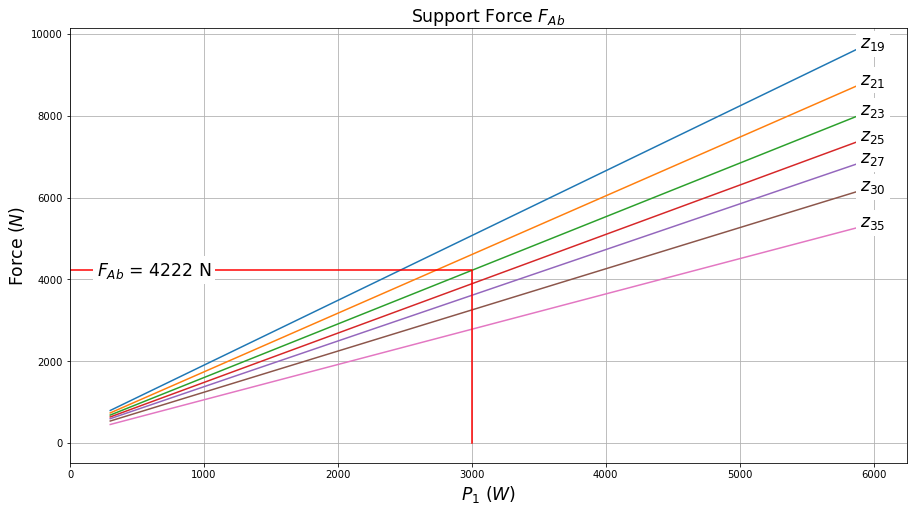

In [17]:
z_1 = np.array([19,21,23,25,27,30,35])

# we want to investigate the change in F_Ab, as a function of P_1

P_1 = np.arange(300,6000,100)                #---Generating an array, form 300W to 6000W steps of 100W

#--- finding the index in P_1 of our 3000 W and 19+ teeth point of interest ---
P_3000_index = np.abs(P_1 - 3000).argmin()
z_19_index = np.abs(z_1 - 23).argmin()


#--- setting X1 and X2 to make code re-usable ---
X1 = P_1
symbol_X1 = 'P_1'
X2 = z_1
symbol_X2 = 'z_1'



#--- Calling the evaluate function itself: ---
#--- as will be demonstrated in other examples, you will be able to evaluate for multiple variables at once ---
yy, A, B = HM.evaluate(CH.F_Ab,{symbol_X1:X1,symbol_X2:X2})   

yy_point = yy[P_3000_index,z_19_index]
print(yy_point)

# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
fig1,ax1 = plt.subplots(1,1,figsize=(15, 8))
# plot the results
t=ax1.plot(X1,yy)
ax1.grid()
#--- Creating a legend based on X1 values. This legend is designed for black-and-white printing and is less suitable for overlapping lines. ---
for i in range(len(X2)):
    label = str(X2[i])
    #--- text to be altered according to graphs ---
    ax1.annotate(f'$z_{{{label}}}$',xy=(X1[-1],yy[-1,i]),xytext=(0,0)     #---in stead of using a legend, we can name the plot 'on the line'
             ,textcoords="offset points",size=textsize
             ,bbox=dict(facecolor='white',edgecolor='none'))

#--- setting the labels for x and y axis ---
ax1.set_title((f'Support Force $F_{{Ab}}$'),fontsize=textsize)
ax1.set_xlabel(f'$P_1$ $(W)$',fontsize=textsize)
t=ax1.set_ylabel(f'Force $(N)$',fontsize=textsize)

#--- indicating the chosen point of interest ---
ax1.plot([0,3000,3000],[yy_point,yy_point,0],color='r')

ax1.annotate(f'$F_{{Ab}}$ = {int(yy_point)} N', xy=(0,0), xytext=(200,4100)
         ,bbox=dict(facecolor='white',edgecolor='none'),xycoords='data',size=textsize)

ax1.set_xlim([0,6250])
t=0

When a DIN 8187 - 16B - 1x120 chain is employed to convey $P_1=3kW$ of power, with the shaft-to-shaft alignment $\psi=40°$ from the horizontal, this results in a support force of $F_{Ab}\approx4230N$ on the upper sprocket shaft.  

Based on the graph above, it can be confirmed that the support force, $F_{Ab}$, exhibits a linear dependence on $P_1,$ as expected. Furthermore, the support force is inversely proportional to the number of teeth, which aligns with our expectations. The tangential reference force, $F_t$, also shows an inverse proportionality to the sprocket diameter, influencing the effect on $F_{Ab}.$  ($Roloff\&Matek^1$)

Upon closer examination, the effect of the number of teeth does not appear to be perfectly linear: $3000W \cdot \frac{35}{23} = 4565W$, which exceeds the expected $4222N$ from a strictly linear proportionality. Plotting $F{Ab}$  as finction of $z_1$ will visualise their specific interdependency.
  
$ .^1$ : Herbert Wittel, Dieter Jannasch, Joachim Voßiek, Christian Spura, *Chapter 16: riemen* in *Roloff/Matek: Machineonderdelen theorieboek (6e druk)* Amsterdam, Boom uitgeverij, 2021,  ISBN: 9789024428670

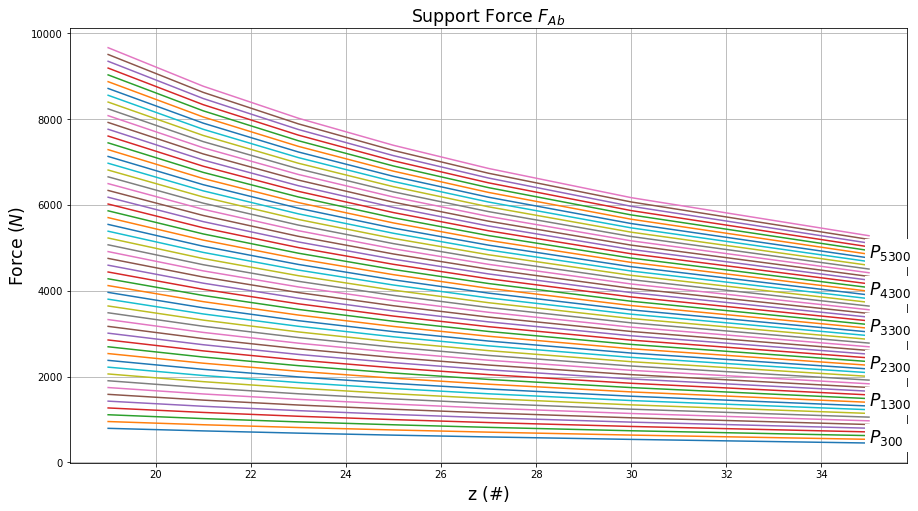

In [18]:
# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
fig2,ax2 = plt.subplots(1,1,figsize=(15, 8))

#--- creating a transposed version of the previous plot, alternatively one could re-run the HM.evaluate, with the X1 and X2 swapped
yy_transposed=np.transpose(yy)
# plot the results
t=ax2.plot(X2,yy_transposed)
ax2.grid()
#--- Creating a legend based on X1 values. This legend is designed for black-and-white printing and is less suitable for overlapping lines. ---
for i in range(len(X1)):
    if i%10==0:     #--- print every other 10th label ---
        label = str(X1[i])
        #--- text to be altered according to graphs ---
        ax2.annotate(f'$P_{{{label}}}$',xy=(X2[-1],yy_transposed[-1,i]),xytext=(0,0)     #---in stead of using a legend, we can name the plot 'on the line'
                 ,textcoords="offset points",size=textsize
                 ,bbox=dict(facecolor='white',edgecolor='none'))

#--- setting the labels for x and y axis ---
ax2.set_title((f'Support Force $F_{{Ab}}$'),fontsize=textsize)
ax2.set_xlabel(f'z $(\#)$',fontsize=textsize)
t=ax2.set_ylabel(f'Force $(N)$',fontsize=textsize)


When calculating the shaft support force, $F_{Ab}$, the impact of reducing the number of teeth becomes increasingly evident when transitioning from a higher to a lower number of teeth. While this effect remains consistent across different values of $P_1$, it is visually more pronounced for higher values of $P_1$ due to the scale of the y-axis.

This outcome aligns with our expectations, as previously noted. As mentioned earlier, the reference tangential force, $F_t$, is inversely proportional to the number of teeth. In fact, for a theoretical number of teeth $z_1=0$, an infinitely large $F_t= \infty$ is expected.

*The resulting figure appears overcrowded, which could be alleviated by selecting alternative values for evaluating the function.*  
*It's didactic purpose was to demostrate the use of transpose*  

*It might look better using a color map*

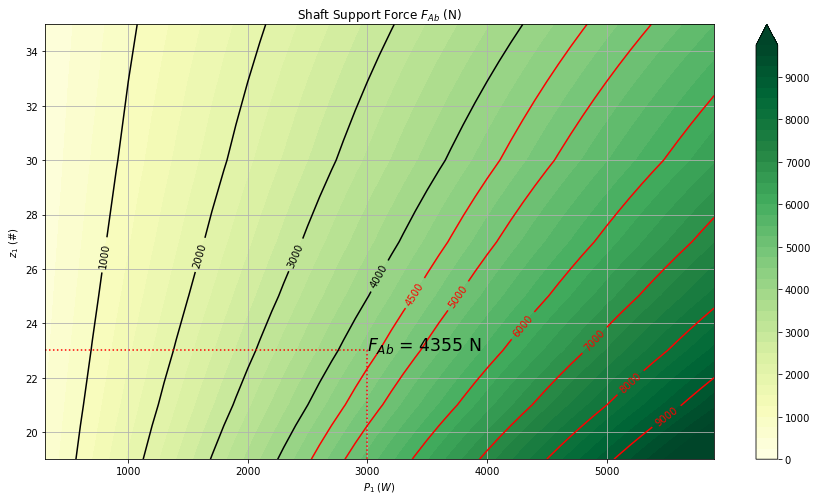

In [39]:
#--- creating a different type of plot, using the same data ---
# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
fig3,ax3 = plt.subplots(1,1,figsize=(15, 8))
cp = ax3.contourf(A,B,yy,levels=range(0,10000,250),extend="max",cmap='YlGn')
plt.colorbar(cp)
#--- adding lines for some specific contour values, assuming 4500 would be a maximum ---
plotLevels=[1000, 2000, 3000, 4000, 4500, 5000,  6000, 7000, 8000,9000]
cp2= ax3.contour(A,B,yy,levels=plotLevels,colors = ['k' if t<4500 else 'r' for t in plotLevels])
plt.clabel(cp2,inline=1)
ax3.set(ylabel=f'$z_1$ (#)',xlabel=f'$P_1$ $(W)$',title=f'Shaft Support Force $F_{{Ab}}$ (N)')
ax3.plot([P_1[0],3000,3000],[23,23,z_1[0]],color='r',linestyle=':')   #--- adding a dotted line with the relevant number of teeht and power ----
ax3.text(3000,23,f'$F_{{Ab}}$ = {int(yy_point)} N',size=textsize)     #--- adding a text with the specific value
ax3.grid()
t=0

*This type of graph can be particularly valuable when dealing with complex, non-monotonic data with local minima and maxima.*  

---

When a DIN 8187 - 16B - 1x120 chain is employed under the condutions in the assignment, this results in a support force of $F_{Ab}\approx4230N$ on the upper sprocket shaft.  This value can, for example, serve as a basis for selecting the appropriate bearings for this shaft. If space constraints pose challenges for selecting suitable bearings, the graph above proves usefull in estimating the effects of increasing the number of teeth on bearing loading forces.

As evident from the graph, for higher values of input power, P_1, the absolute impact of increasing the number of teeth on the reduction of the shaft support force $F_{Ab}$ is more pronounced.  Again an expected result beacause $F_{Ab}$ is inverse proportional to the number of teeth $z_1$.

---
*Let's explore another option for visualizing data.*

In [23]:
#P_D is a function of both P_1 and z_1
t=HM.EqPrint('P_D',CH.P_D)

Eq(P_D, 40.3*_P_1*(1/_z_1)**1.06)

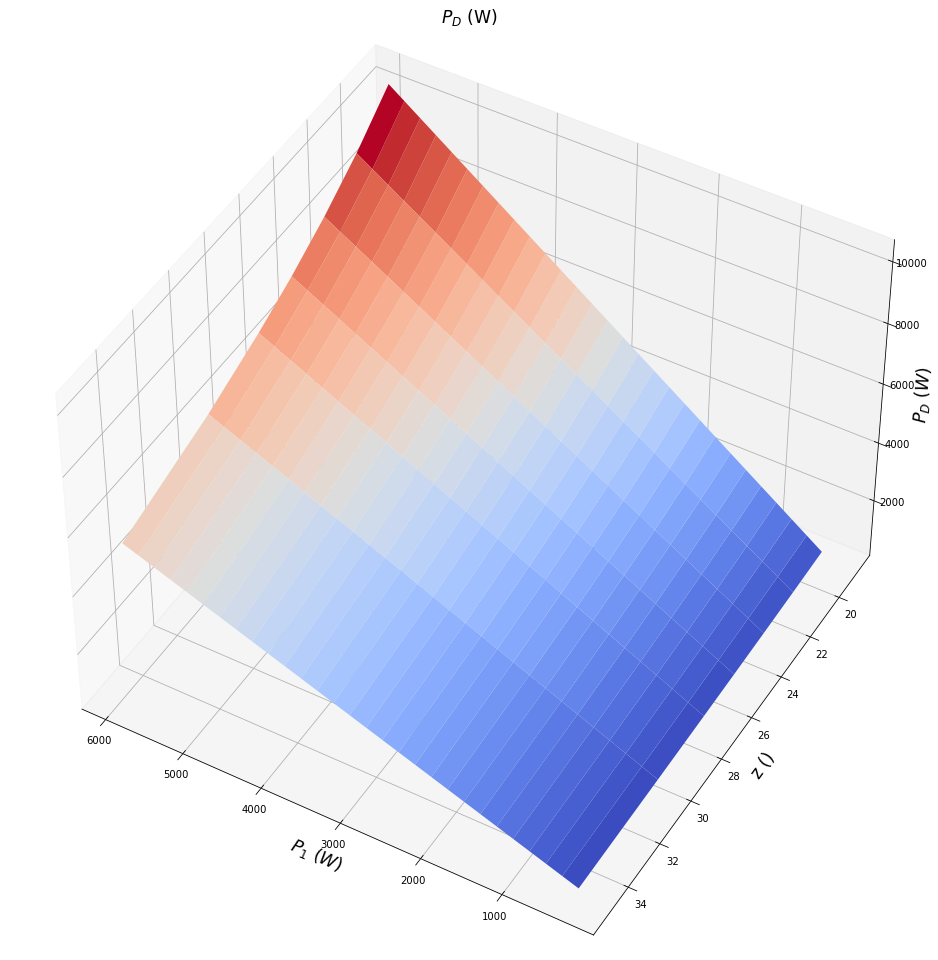

In [25]:
#--- creating a different type of plot, using the same data ---

#evaluating P_D for the above values for P_1 and z_1
yy, A, B = HM.evaluate(CH.P_D,{symbol_X1:X1,symbol_X2:X2})   


# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
fig4,ax4 = plt.subplots(1,1,figsize=(17, 17),subplot_kw={"projection": "3d"})
# plot the results
t=ax4.plot_surface(A,B,yy,cmap=plt.cm.coolwarm, linewidth=0)

ax4.set_xlabel(f'$P_1$ $(W)$',fontsize=textsize)
ax4.set_ylabel(f'z $()$',fontsize=textsize)
ax4.set_title(f'$P_D$ (W)',fontsize=textsize)
ax4.set_zlabel(f'$P_D$ $(W)$',fontsize=textsize)

#­--- changing the angle of view ---
ax4.view_init(45,120)   #---45° upward and 120° along z axis---

*While this format provides an initial impression of how your data will appear, it may not be ideal for precise value extraction.*  

*Let's switch back to contour plots*

4355.580439538388


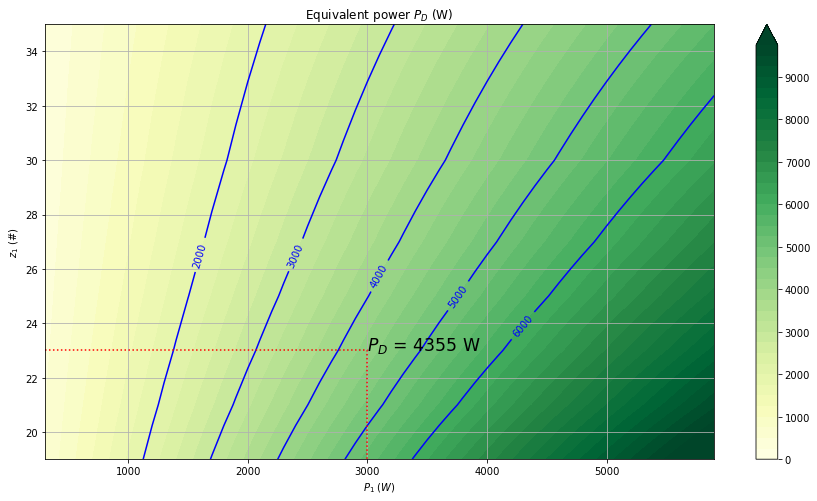

In [42]:
fig5,ax5 = plt.subplots(1,1,figsize=(15, 8))

yy_point = yy[P_3000_index,z_19_index]
print(yy_point)
cp = ax5.contourf(A,B,yy,levels=range(0,10000,250),extend="max",cmap='YlGn')
plt.colorbar(cp)
#--- adding lines for some specific contour values, assuming 4500 would be a maximum ---
#The orders of magnitude for the absolute values of F_Ab and P_D happen to be coincidentally equal
plotLevels=[2000, 3000, 4000, 5000,  6000, ]    
#for a speed of 125 rpm, the different maximum values for different chains are used
cp2= ax5.contour(A,B,yy,levels=plotLevels,colors = ['k' if t<2000 else 'b' if t<=6000 else 'r' if t<10100 else 'm' for t in plotLevels])
plt.clabel(cp2,inline=1)
ax5.set(ylabel=f'$z_1$ (#)',xlabel=f'$P_1$ $(W)$',title=f'Equivalent power $P_D$ (W)')
ax5.plot([P_1[0],3000,3000],[23,23,z_1[0]],color='r',linestyle=':')   #--- adding a dotted line with the relevant number of teeht and power ----
ax5.text(3000,23,f'$P_D$ = {int(yy_point)} W',size=textsize)     #--- adding a text with the specific value
ax5.grid()
t=0

Given the specific values from the assignment, the reference power $P_D=4355W$. The selected DIN 8187 - 16B - 1x120 chain is used well within it's operating conditions. The same chain would be selected for all testd values of the number of teeth on the first sprocket ($z_1$). Only when the power to be transmitted would increase to $P_1=6kW$, a more havy duty 20B chain would be advised.  
  

---
**The primary goal of this file is to provide an introduction to graph creation rather than delving into an in-depth analysis of the chain solution. For simplicity, certain parameters such as f_2 are held constant at a value of 1, and the pitch and shaft-to-shaft distance do not accurately depend on the number of teeth.  
While it is feasible to achieve this by adding additional code and incorporating if statements, it was deemed that such details would detract from the main objective: introducing various types of graphs.**  
---